# Objective :
### Test which timing (3 hr, 6 hrs, 18 hrs) for sending cart abandonment emails leads to highest return-to-purchase rate.

In [2]:
import pandas as pd
df=pd.read_csv("user_return_data.csv")
# Show the first few rows
print(df.head())


  user_id group  returned  delay_to_return_hr
0   1hr_0   1hr     False                 NaN
1   1hr_1   1hr     False                 NaN
2   1hr_2   1hr     False                 NaN
3   1hr_3   1hr     False                 NaN
4   1hr_4   1hr      True            0.169596


In [10]:
# conduct power analysis 
from statsmodels.stats.power import TTestPower
power_analysis = TTestPower()  
sample_size = power_analysis.solve_power(effect_size=0.2, alpha=0.05, power=0.8, alternative='larger')
print(f"Minimum sample size needed for the test: {sample_size:.0f}")

Minimum sample size needed for the test: 156


In [11]:
#count of users per group
group_counts = df['group'].value_counts()
print("Count of users per group:")
print(group_counts)

Count of users per group:
group
1hr     1000
6hr     1000
24hr    1000
Name: count, dtype: int64


In [ ]:
#Return-to-purchase rates by timing group.

return_rates = df[df['returned'] == True].groupby('group')['user_id'].count() / df.groupby('group')['user_id'].count()
print("Return rates by group:")
print(return_rates)



Return rates by group:
group
1hr     0.262
24hr    0.290
6hr     0.309
Name: user_id, dtype: float64


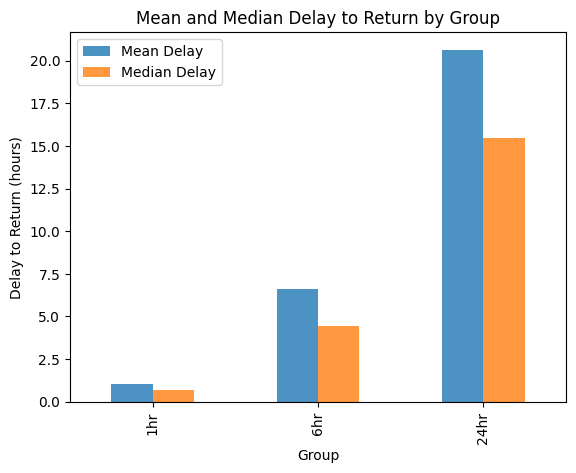

In [18]:
# Mean/median delay_to_return_hr in each group
import matplotlib.pyplot as plt

mean_delay = df.groupby('group')['delay_to_return_hr'].mean()
median_delay = df.groupby('group')['delay_to_return_hr'].median()

# Combine into a DataFrame for side-by-side bars
desired_order = ['1hr', '6hr', '24hr']
delay_df = delay_df.reindex(desired_order)

# Plot side by side
delay_df.plot(kind='bar', alpha=0.8)
plt.title('Mean and Median Delay to Return by Group')
plt.xlabel('Group')
plt.ylabel('Delay to Return (hours)')
plt.legend()
plt.show()


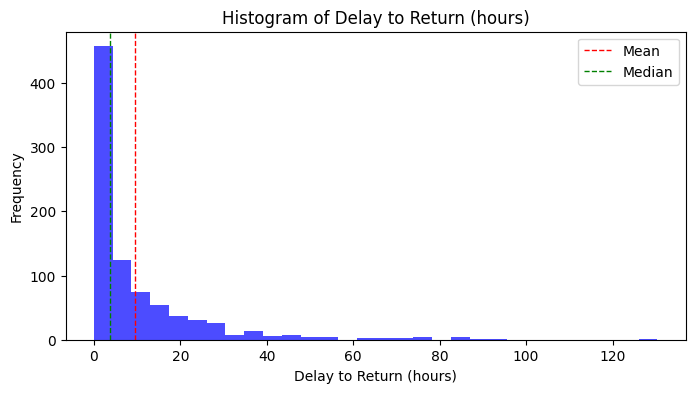

Mean delay to return: 9.64260086058082
Median delay to return: 3.7269196767547


In [21]:
# plot histogram of delay_to_return_hr
plt.figure(figsize=(8, 4))
plt.hist(df['delay_to_return_hr'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Delay to Return (hours)')
plt.xlabel('Delay to Return (hours)')
plt.ylabel('Frequency')
plt.axvline(df['delay_to_return_hr'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['delay_to_return_hr'].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.show()
print("Mean delay to return:", df['delay_to_return_hr'].mean())
print("Median delay to return:", df['delay_to_return_hr'].median())


## Statistical Testing

In [ ]:
# return rate analysis
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['group'], df['returned'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)
print('Contingency_table:')
print(contingency_table)
print(f"Chi-Square Test: chi2 = {chi2:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: Return rate is dependent on timing group.")
else:
    print("Fail to reject the null hypothesis: Return rate is independent of timing group.")


Contingency_table:
returned  False  True 
group                 
1hr         738    262
24hr        710    290
6hr         691    309
Chi-Square Test: chi2 = 5.4635, p-value = 0.0651
Fail to reject the null hypothesis: Return rate is independent of timing group.


## Normality test

Shapiro-Wilk Test for 1hr: W=0.8436, p=0.0000
  -> Data in '1hr' is likely **not normally distributed** (reject H0)
Shapiro-Wilk Test for 6hr: W=0.8342, p=0.0000
  -> Data in '6hr' is likely **not normally distributed** (reject H0)
Shapiro-Wilk Test for 24hr: W=0.8190, p=0.0000
  -> Data in '24hr' is likely **not normally distributed** (reject H0)


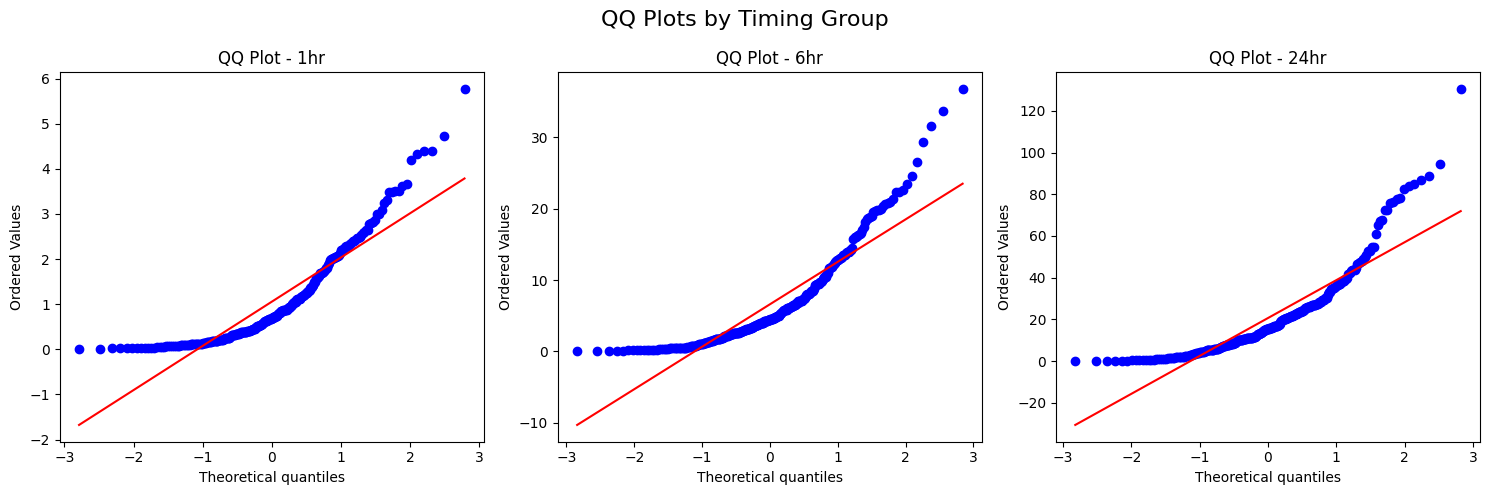

In [31]:
import scipy.stats as stats

timing_groups = df['group'].unique()

# Set up subplots for QQ plots
fig, axes = plt.subplots(1, len(timing_groups), figsize=(5 * len(timing_groups), 5))
fig.suptitle('QQ Plots by Timing Group', fontsize=16)

# Perform Shapiro-Wilk test and QQ plot for each group
for i, group in enumerate(timing_groups):
    group_data = df[df['group'] == group]['delay_to_return_hr'].dropna()
    
    # QQ plot
    stats.probplot(group_data, dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ Plot - {group}')
    
    # Shapiro-Wilk test
    stat, p = stats.shapiro(group_data)
    print(f"Shapiro-Wilk Test for {group}: W={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        print(f"  -> Data in '{group}' is likely **not normally distributed** (reject H0)")
    else:
        print(f"  -> Data in '{group}' is likely **normally distributed** (fail to reject H0)")

plt.tight_layout()
plt.show()

#### Since time taken for user to return follow a exponential distribution which is right skewed i.e. non normal , hence we'll follow a non parametric test

## Kruskal-Wallis H test

In [45]:
from scipy.stats import kruskal

# Create separate arrays for each group
group_1hr = df[df['group'] == '1hr']['delay_to_return_hr'].dropna()
group_6hrs = df[df['group'] == '6hr']['delay_to_return_hr'].dropna()
group_24hrs = df[df['group'] == '24hr']['delay_to_return_hr'].dropna()

# Perform Kruskal-Wallis Test
stat, p = kruskal(group_1hr, group_6hrs, group_24hrs) 

print(f"Kruskal-Wallis H-test: H={stat:.4f}, p={p:.4f}")
if p < 0.05:
    print("  -> Significant differences in delay-to-return across groups.")
else:
    print("  -> No significant differences in delay-to-return across groups.")


Kruskal-Wallis H-test: H=433.2935, p=0.0000
  -> Significant differences in delay-to-return across groups.


## Pairwise Test

In [63]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import itertools

groups = df['group'].unique()
pairs = list(itertools.combinations(groups, 2))

p_values = []
pair_names = []

# Mann-Whitney U for all pairs
for g1, g2 in pairs:
    data1 = df[df['group'] == g1]['delay_to_return_hr'].dropna()
    data2 = df[df['group'] == g2]['delay_to_return_hr'].dropna()
    stat, p = mannwhitneyu(data1, data2, alternative='less')
    p_values.append(p)
    pair_names.append(f"{g1} vs {g2}")

# Multiple testing correction (Holm is more powerful than Bonferroni)
corrected = multipletests(p_values, method='holm')  # or 'fdr_bh'

# Show results
for i, (raw_p, adj_p, name) in enumerate(zip(p_values, corrected[1], pair_names)):
    print(f"{name}: raw p = {raw_p:.4f}, adjusted p = {adj_p:.4f}")


1hr vs 6hr: raw p = 0.0000, adjusted p = 0.0000
1hr vs 24hr: raw p = 0.0000, adjusted p = 0.0000
6hr vs 24hr: raw p = 0.0000, adjusted p = 0.0000


## Effect Size

In [68]:
# calculate effect size using Cohen's d

import numpy as np

def cohen_d(x, y):
    """Calculate Cohen's d for two independent samples."""
    x = np.array(x)
    y = np.array(y)
    
    nx = len(x)
    ny = len(y)
    
    # Means
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Standard deviations
    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)

    # Pooled standard deviation
    pooled_std = np.sqrt(((nx - 1)*std_x**2 + (ny - 1)*std_y**2) / (nx + ny - 2))

    d = (mean_x - mean_y) / pooled_std
    return d


groups = df['group'].unique()
pairs = list(itertools.combinations(groups, 2))

p_values = []
pair_names = []

# Mann-Whitney U for all pairs
for g1, g2 in pairs:
    data1 = df[df['group'] == g1]['delay_to_return_hr'].dropna()
    data2 = df[df['group'] == g2]['delay_to_return_hr'].dropna()
    effect_size = cohen_d(data2, data1)
    print(f"Cohen's d for {g2} vs {g1}: {effect_size:.4f}")
    
if effect_size > 0.8:
    print("Effect size indicates a large difference between groups.")
elif effect_size > 0.5:
    print("Effect size indicates a medium difference between groups.")
elif effect_size > 0.2:
    print("Effect size indicates a small difference between groups.")
else:
    print("Effect size indicates no meaningful difference between groups.")    

Cohen's d for 6hr vs 1hr: 1.1495
Cohen's d for 24hr vs 1hr: 1.3518
Cohen's d for 24hr vs 6hr: 0.9589
Effect size indicates a large difference between groups.
